# Deep Learning for Casting Product Quality Inspection

This notebook evaluates two deep learning models for binary classification of casting product images.

The task is to classify each image into:

- `def_front`: Defective product
- `ok_front`: Acceptable product

Based on the previous classical machine learning experiments, two deep learning candidates are selected:

1. ResNet18
2. EfficientNet-B0

The same train, validation, and test datasets are used throughout the experiment.

### Evaluation strategy

- Training set: used for model training
- Validation set: used for model comparison and selection
- Test set: kept untouched until final evaluation

The main metrics are:

- Accuracy
- Precision
- Recall
- F1-score

Special attention is given to defective products because missing a defective product is important in industrial quality inspection.

## 1. Import Libraries

Import the libraries required for dataset loading, deep learning, training, and evaluation.

In [1]:
from pathlib import Path

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2. Reproducibility and Device

Set a fixed random seed so that the experiment can be reproduced.

Use GPU when available.

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


## 3. Dataset Path

The dataset is stored in:

```text
data/
└── raw/
    └── casting_data/
        └── casting_data/
            ├── train/
            │   ├── def_front/
            │   └── ok_front/
            └── test/
                ├── def_front/
                └── ok_front/
```

In [3]:
# Project root
PROJECT_ROOT = Path(r"D:\Casting Quality Inspection")

# Dataset path
DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "casting_data"
    / "casting_data"
)

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

print("Dataset:", DATA_DIR)
print("Train:", TRAIN_DIR)
print("Test:", TEST_DIR)

Dataset: D:\Casting Quality Inspection\data\raw\casting_data\casting_data
Train: D:\Casting Quality Inspection\data\raw\casting_data\casting_data\train
Test: D:\Casting Quality Inspection\data\raw\casting_data\casting_data\test


In [4]:
print("Train folder exists:", TRAIN_DIR.exists())
print("Test folder exists:", TEST_DIR.exists())

Train folder exists: True
Test folder exists: True


## 4. Image Transformations

Images are resized to 224 × 224 pixels.

Training images use light augmentation.

Validation and test images are only resized and normalized.

The test set is never augmented.

In [5]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 5. Load Dataset

The original training folder is split into training and validation subsets.

Separate dataset objects are created so that:

- Training uses augmentation
- Validation does not use augmentation
- Test does not use augmentation

In [6]:
train_data = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_data = datasets.ImageFolder(
    TRAIN_DIR,
    transform=eval_transform
)

test_data = datasets.ImageFolder(
    TEST_DIR,
    transform=eval_transform
)

print("Classes:", train_data.classes)
print("Training folder:", len(train_data))
print("Test images:", len(test_data))

Classes: ['def_front', 'ok_front']
Training folder: 6633
Test images: 715


## 6. Train / Validation Split

The training folder is split into training and validation subsets.

A fixed seed is used to keep the split reproducible.

The test set remains completely separate.

In [7]:
VAL_RATIO = 0.2

generator = torch.Generator().manual_seed(SEED)

indices = torch.randperm(
    len(train_data),
    generator=generator
).tolist()

val_size = int(len(indices) * VAL_RATIO)

val_indices = indices[:val_size]
train_indices = indices[val_size:]

train_dataset = Subset(
    train_data,
    train_indices
)

val_dataset = Subset(
    val_data,
    val_indices
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_data))

Training images: 5307
Validation images: 1326
Test images: 715


Expected split:

```text
Training images: 5307
Validation images: 1326
Test images: 715
```

## 7. DataLoaders

Only the training loader shuffles the data.

In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 166
Validation batches: 42
Test batches: 23


## 8. Check One Batch

Check the image and label shapes before training.

In [9]:
images, labels = next(iter(train_loader))

print("Image shape:", images.shape)
print("Label shape:", labels.shape)
print("Labels:", labels[:10])

Image shape: torch.Size([32, 3, 224, 224])
Label shape: torch.Size([32])
Labels: tensor([1, 0, 0, 0, 0, 0, 1, 1, 1, 0])


## 9. Training Function

In [10]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    loss = total_loss / total
    accuracy = correct / total

    return loss, accuracy

## 10. Evaluation Function

Evaluate a model without updating its weights.

Macro averaging is used so both classes contribute equally to the overall metrics.

In [11]:
def evaluate_model(model, loader):

    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            predictions = outputs.argmax(dim=1)

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    precision = precision_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "labels": all_labels,
        "predictions": all_predictions
    }

## 11. Training Pipeline

Train a model and keep the version with the best validation F1-score.

The validation set is used for model selection.

In [12]:
def train_model(
    model,
    model_name,
    epochs=10,
    learning_rate=0.0001
):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
        "val_f1": []
    }

    best_f1 = -1
    best_state = None

    for epoch in range(epochs):

        train_loss, train_accuracy = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_result = evaluate_model(
            model,
            val_loader
        )

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_result["accuracy"])
        history["val_f1"].append(val_result["f1"])

        print(
            f"{model_name} | "
            f"Epoch {epoch + 1}/{epochs} | "
            f"Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Acc: {val_result['accuracy']:.4f} | "
            f"Val F1: {val_result['f1']:.4f}"
        )

        # Keep the best validation model
        if val_result["f1"] > best_f1:

            best_f1 = val_result["f1"]

            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

    # Restore best model
    model.load_state_dict(best_state)

    print()
    print("Best validation F1:", round(best_f1, 4))

    return model, history

# 12. ResNet18

ResNet18 is the first deep learning candidate.

A pretrained ImageNet model is used and the final classification layer is replaced with a two-class classifier.

In [13]:
resnet18 = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

resnet18.fc = nn.Linear(
    resnet18.fc.in_features,
    2
)

resnet18 = resnet18.to(device)

print(resnet18.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Hello/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 57.7MB/s]


Linear(in_features=512, out_features=2, bias=True)


## 13. Train ResNet18

In [14]:
resnet18, history_resnet18 = train_model(
    resnet18,
    model_name="ResNet18",
    epochs=10,
    learning_rate=0.0001
)

ResNet18 | Epoch 1/10 | Loss: 0.0877 | Train Acc: 0.9670 | Val Acc: 0.9955 | Val F1: 0.9954
ResNet18 | Epoch 2/10 | Loss: 0.0186 | Train Acc: 0.9953 | Val Acc: 0.9977 | Val F1: 0.9977
ResNet18 | Epoch 3/10 | Loss: 0.0176 | Train Acc: 0.9938 | Val Acc: 0.9985 | Val F1: 0.9985
ResNet18 | Epoch 4/10 | Loss: 0.0115 | Train Acc: 0.9962 | Val Acc: 0.9985 | Val F1: 0.9985
ResNet18 | Epoch 5/10 | Loss: 0.0102 | Train Acc: 0.9962 | Val Acc: 0.9570 | Val F1: 0.9568
ResNet18 | Epoch 6/10 | Loss: 0.0204 | Train Acc: 0.9925 | Val Acc: 0.9992 | Val F1: 0.9992
ResNet18 | Epoch 7/10 | Loss: 0.0121 | Train Acc: 0.9960 | Val Acc: 0.9985 | Val F1: 0.9985
ResNet18 | Epoch 8/10 | Loss: 0.0089 | Train Acc: 0.9972 | Val Acc: 0.9985 | Val F1: 0.9985
ResNet18 | Epoch 9/10 | Loss: 0.0082 | Train Acc: 0.9972 | Val Acc: 0.9962 | Val F1: 0.9962
ResNet18 | Epoch 10/10 | Loss: 0.0105 | Train Acc: 0.9960 | Val Acc: 0.9962 | Val F1: 0.9962

Best validation F1: 0.9992


## 14. ResNet18 Training Loss

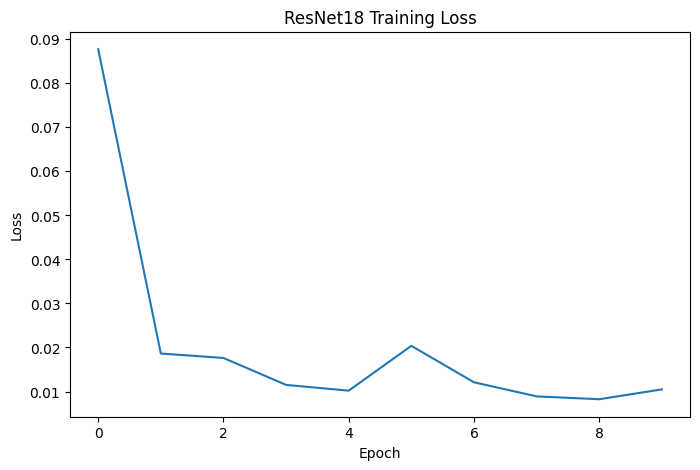

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_resnet18["train_loss"]
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 Training Loss")

plt.show()

## 15. ResNet18 Training Performance

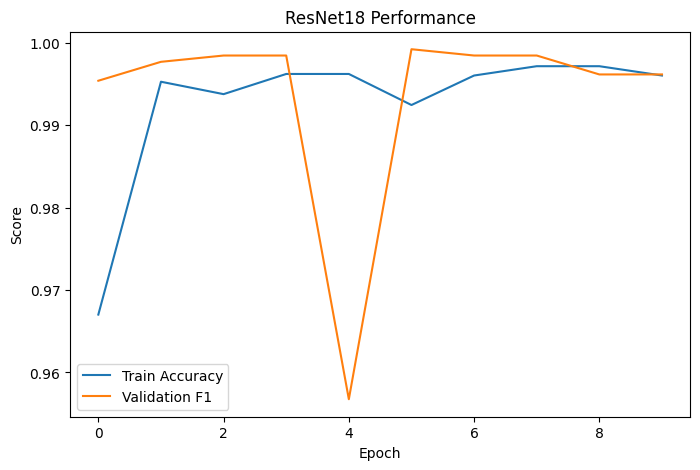

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_resnet18["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_resnet18["val_f1"],
    label="Validation F1"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("ResNet18 Performance")

plt.legend()
plt.show()

## 16. ResNet18 Validation Results

In [17]:
resnet18_val = evaluate_model(
    resnet18,
    val_loader
)

print(
    classification_report(
        resnet18_val["labels"],
        resnet18_val["predictions"],
        target_names=train_data.classes,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

   def_front     1.0000    0.9987    0.9993       743
    ok_front     0.9983    1.0000    0.9991       583

    accuracy                         0.9992      1326
   macro avg     0.9991    0.9993    0.9992      1326
weighted avg     0.9992    0.9992    0.9992      1326



# 17. EfficientNet-B0

EfficientNet-B0 is the second deep learning candidate.

It provides a different CNN architecture while remaining relatively lightweight.

In [18]:
efficientnet = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

efficientnet.classifier[1] = nn.Linear(
    efficientnet.classifier[1].in_features,
    2
)

efficientnet = efficientnet.to(device)

print(efficientnet.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Hello/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 35.1MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


## 18. Train EfficientNet-B0

In [19]:
efficientnet, history_efficientnet = train_model(
    efficientnet,
    model_name="EfficientNet-B0",
    epochs=10,
    learning_rate=0.0001
)

EfficientNet-B0 | Epoch 1/10 | Loss: 0.1340 | Train Acc: 0.9595 | Val Acc: 0.9985 | Val F1: 0.9985
EfficientNet-B0 | Epoch 2/10 | Loss: 0.0247 | Train Acc: 0.9923 | Val Acc: 0.9985 | Val F1: 0.9985
EfficientNet-B0 | Epoch 3/10 | Loss: 0.0155 | Train Acc: 0.9949 | Val Acc: 0.9985 | Val F1: 0.9985
EfficientNet-B0 | Epoch 4/10 | Loss: 0.0137 | Train Acc: 0.9953 | Val Acc: 0.9985 | Val F1: 0.9985
EfficientNet-B0 | Epoch 5/10 | Loss: 0.0109 | Train Acc: 0.9964 | Val Acc: 0.9955 | Val F1: 0.9954
EfficientNet-B0 | Epoch 6/10 | Loss: 0.0109 | Train Acc: 0.9960 | Val Acc: 0.9985 | Val F1: 0.9985
EfficientNet-B0 | Epoch 7/10 | Loss: 0.0100 | Train Acc: 0.9962 | Val Acc: 0.9985 | Val F1: 0.9985
EfficientNet-B0 | Epoch 8/10 | Loss: 0.0081 | Train Acc: 0.9972 | Val Acc: 0.9985 | Val F1: 0.9985
EfficientNet-B0 | Epoch 9/10 | Loss: 0.0099 | Train Acc: 0.9968 | Val Acc: 0.9985 | Val F1: 0.9985
EfficientNet-B0 | Epoch 10/10 | Loss: 0.0089 | Train Acc: 0.9972 | Val Acc: 0.9985 | Val F1: 0.9985

Best val

## 19. EfficientNet-B0 Training Loss

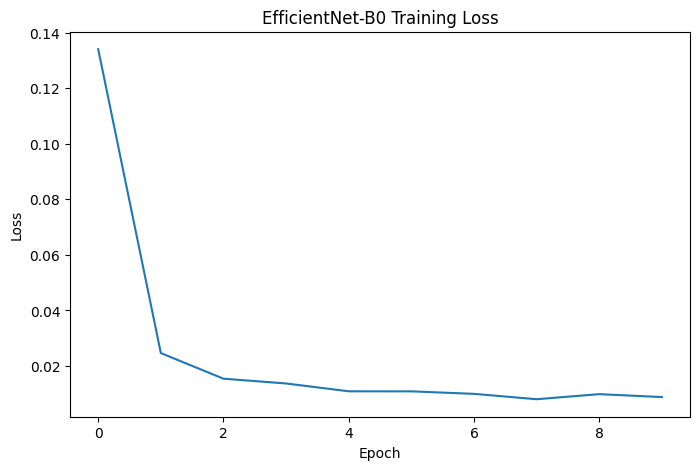

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_efficientnet["train_loss"]
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 Training Loss")

plt.show()

## 20. EfficientNet-B0 Training Performance

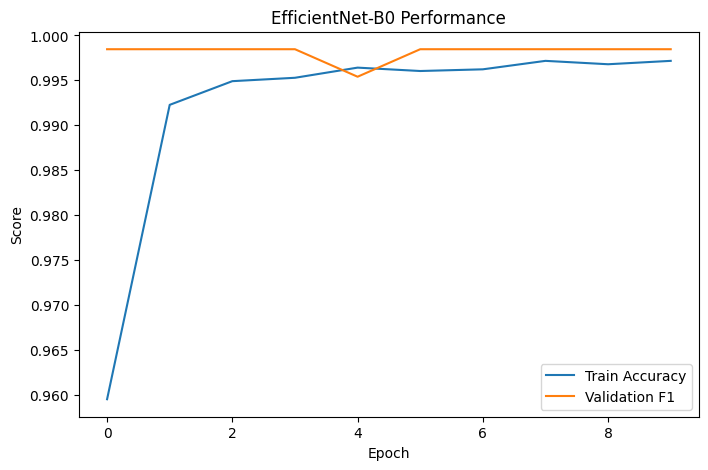

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_efficientnet["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_efficientnet["val_f1"],
    label="Validation F1"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("EfficientNet-B0 Performance")

plt.legend()
plt.show()

## 21. EfficientNet-B0 Validation Results

In [22]:
efficientnet_val = evaluate_model(
    efficientnet,
    val_loader
)

print(
    classification_report(
        efficientnet_val["labels"],
        efficientnet_val["predictions"],
        target_names=train_data.classes,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

   def_front     1.0000    0.9973    0.9987       743
    ok_front     0.9966    1.0000    0.9983       583

    accuracy                         0.9985      1326
   macro avg     0.9983    0.9987    0.9985      1326
weighted avg     0.9985    0.9985    0.9985      1326



# 22. Model Comparison

Compare ResNet18 and EfficientNet-B0 using the validation set.

The test set is not used for model selection.

In [23]:
comparison = pd.DataFrame([
    {
        "Model": "ResNet18",
        "Accuracy": resnet18_val["accuracy"],
        "Precision": resnet18_val["precision"],
        "Recall": resnet18_val["recall"],
        "F1": resnet18_val["f1"]
    },
    {
        "Model": "EfficientNet-B0",
        "Accuracy": efficientnet_val["accuracy"],
        "Precision": efficientnet_val["precision"],
        "Recall": efficientnet_val["recall"],
        "F1": efficientnet_val["f1"]
    }
])

comparison = comparison.sort_values(
    "F1",
    ascending=False
).reset_index(drop=True)

comparison

,Model,Accuracy,Precision,Recall,F1
0,ResNet18,0.999246,0.999144,0.999327,0.999235
1,EfficientNet-B0,0.998492,0.998291,0.998654,0.998470


## 23. Select the Best Model

The model with the highest validation F1-score is selected.

The test set remains untouched.

In [24]:
best_model_name = comparison.iloc[0]["Model"]

print("Best model:", best_model_name)

Best model: ResNet18


In [25]:
if best_model_name == "ResNet18":

    best_model = resnet18
    best_val_result = resnet18_val

else:

    best_model = efficientnet
    best_val_result = efficientnet_val

print("Selected model:", best_model_name)
print(
    f"Validation F1: "
    f"{best_val_result['f1']:.4f}"
)

Selected model: ResNet18
Validation F1: 0.9992


# 24. Final Test Evaluation

The test set has not been used for training or model selection.

The selected model is now evaluated on the held-out test set.

This is the final deep learning result.

In [26]:
test_result = evaluate_model(
    best_model,
    test_loader
)

print(
    classification_report(
        test_result["labels"],
        test_result["predictions"],
        target_names=test_data.classes,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

   def_front     1.0000    0.9978    0.9989       453
    ok_front     0.9962    1.0000    0.9981       262

    accuracy                         0.9986       715
   macro avg     0.9981    0.9989    0.9985       715
weighted avg     0.9986    0.9986    0.9986       715



In [27]:
print(
    f"Test Accuracy : {test_result['accuracy']:.4f}"
)

print(
    f"Test Precision: {test_result['precision']:.4f}"
)

print(
    f"Test Recall   : {test_result['recall']:.4f}"
)

print(
    f"Test F1       : {test_result['f1']:.4f}"
)

Test Accuracy : 0.9986
Test Precision: 0.9981
Test Recall   : 0.9989
Test F1       : 0.9985


## 25. Confusion Matrix

Inspect the final test predictions to understand classification errors.

[[452   1]
 [  0 262]]


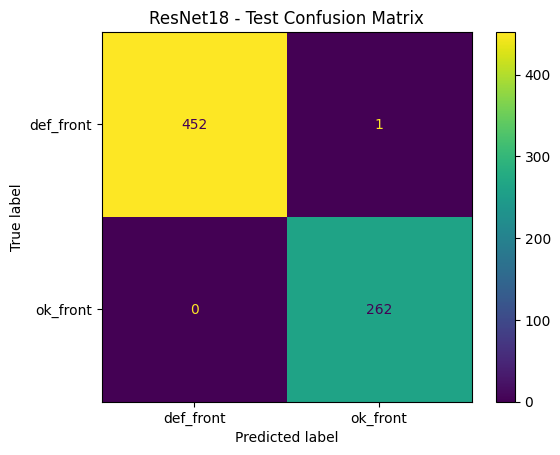

In [28]:
cm = confusion_matrix(
    test_result["labels"],
    test_result["predictions"]
)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_data.classes
)

disp.plot()

plt.title(
    f"{best_model_name} - Test Confusion Matrix"
)

plt.show()

## 26. Defective Product Metrics

For industrial quality inspection, missing a defective product is particularly important.

Report precision and recall for `def_front` separately.

In [29]:
report = classification_report(
    test_result["labels"],
    test_result["predictions"],
    target_names=test_data.classes,
    output_dict=True,
    zero_division=0
)

print(
    "Defective recall:",
    f"{report['def_front']['recall']:.4f}"
)

print(
    "Defective precision:",
    f"{report['def_front']['precision']:.4f}"
)

Defective recall: 0.9978
Defective precision: 1.0000


## 27. Classical ML vs Deep Learning

The best deep learning model is compared with the previous classical machine learning baseline.

The previous Histogram + SVM model achieved:

- 714 correct predictions
- 1 incorrect prediction
- 99.86% test accuracy

This comparison shows whether deep learning provides a meaningful improvement over handcrafted features.

In [30]:
classical_accuracy = 714 / 715

final_comparison = pd.DataFrame([
    {
        "Approach": "Classical ML",
        "Model": "Histogram + SVM",
        "Test Accuracy": classical_accuracy
    },
    {
        "Approach": "Deep Learning",
        "Model": best_model_name,
        "Test Accuracy": test_result["accuracy"]
    }
])

final_comparison

,Approach,Model,Test Accuracy
0,Classical ML,Histogram + SVM,0.998601
1,Deep Learning,ResNet18,0.998601


# 28. Summary

Two deep learning architectures were evaluated:

- ResNet18
- EfficientNet-B0

The models were trained using the same train/validation split.

The validation set was used for model selection, while the test set was kept untouched until the final evaluation.

The selected deep learning model is compared with the classical machine learning baseline, Histogram + SVM.

The results provide an empirical comparison between handcrafted features and learned deep visual representations for casting product quality inspection.

### Next Step

The next stage is error analysis.

Misclassified images will be inspected to understand:

- Small or subtle defects
- Lighting differences
- Camera angle variations
- Image quality
- Difficult defect patterns

The analysis will also provide a foundation for future defect localization using techniques such as Grad-CAM.

Number of misclassified images: 1
Index       : 122
Image       : D:\Casting Quality Inspection\data\raw\casting_data\casting_data\test\def_front\cast_def_0_1591.jpeg
True label  : def_front
Predicted   : ok_front


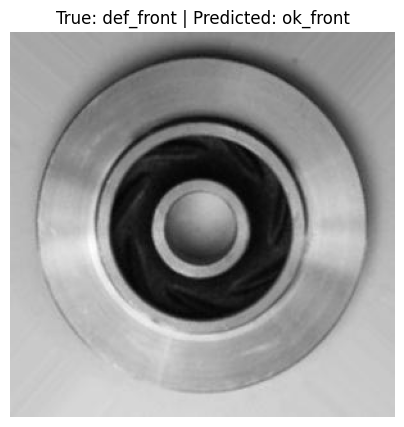

In [31]:
# ============================================================
# Display Misclassified Test Images
# ============================================================
# test_loader uses shuffle=False, so the prediction order
# matches test_data.samples exactly.
# ============================================================

from PIL import Image
import matplotlib.pyplot as plt

wrong_indices = []

for i, (true_label, pred_label) in enumerate(
    zip(
        test_result["labels"],
        test_result["predictions"]
    )
):
    if true_label != pred_label:
        wrong_indices.append(i)


print("Number of misclassified images:", len(wrong_indices))

# Display every misclassified image
for idx in wrong_indices:

    image_path, true_label = test_data.samples[idx]

    pred_label = test_result["predictions"][idx]

    image = Image.open(image_path).convert("RGB")

    print("=" * 60)
    print("Index       :", idx)
    print("Image       :", image_path)
    print("True label  :", test_data.classes[true_label])
    print("Predicted   :", test_data.classes[pred_label])

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(
        f"True: {test_data.classes[true_label]} | "
        f"Predicted: {test_data.classes[pred_label]}"
    )
    plt.axis("off")
    plt.show()